# Lab 02 - Advanced Vision Tasks

In this lab, we will cover:
1. Image Classification (CIFAR-10)
2. Object Detection (Faster R-CNN)
3. Image Segmentation (DeepLabV3)

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 1: Image Classification (CIFAR-10)
We will train a simple CNN on the CIFAR-10 dataset.

In [2]:
# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 5
LEARNING_RATE = 0.001

# Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Data Loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:01<00:00, 106MB/s]  


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)



In [ ]:
for epoch in range(NUM_EPOCHS):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Starting Training...
Epoch [1/5], Step [100/391], Loss: 1.2893
Epoch [1/5], Step [200/391], Loss: 1.1982
Epoch [1/5], Step [300/391], Loss: 1.2823
Epoch [2/5], Step [100/391], Loss: 1.0475
Epoch [2/5], Step [200/391], Loss: 1.0428
Epoch [2/5], Step [300/391], Loss: 0.9173
Epoch [3/5], Step [100/391], Loss: 0.7365
Epoch [3/5], Step [200/391], Loss: 0.7453
Epoch [3/5], Step [300/391], Loss: 0.7739
Epoch [4/5], Step [100/391], Loss: 0.6418
Epoch [4/5], Step [200/391], Loss: 0.6992
Epoch [4/5], Step [300/391], Loss: 0.7717
Epoch [5/5], Step [100/391], Loss: 0.4529
Epoch [5/5], Step [200/391], Loss: 0.5402
Epoch [5/5], Step [300/391], Loss: 0.5943


In [5]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the model on the 10000 test images: {100 * correct / total} %')

Accuracy of the model on the 10000 test images: 71.93 %


## Part 2: Object Detection
We will use a pre-trained Faster R-CNN model.

/Users/fareessiddiqui/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/fareessiddiqui/Library/Python/3.11/lib/python/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/fareessiddiqui/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:05<00:00, 29.1MB/s] 


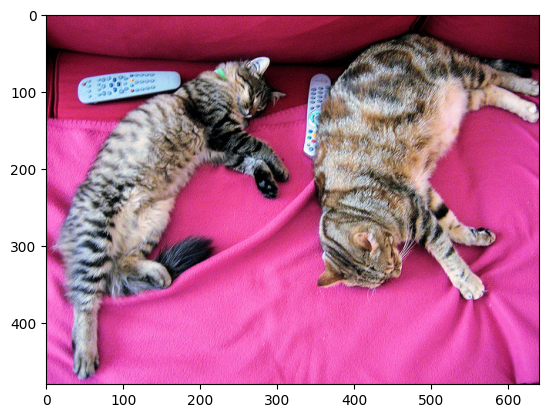

In [2]:
# Load pre-trained model
model_det = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model_det.eval().to(device)

# Download a sample image
img ='data/cats.jpg'
image = Image.open(img).convert("RGB")
plt.imshow(image)
plt.show()

# Transform image
transform_det = transforms.Compose([transforms.ToTensor()])
img_tensor = transform_det(image).to(device).unsqueeze(0)

# Inference
with torch.no_grad():
    prediction = model_det(img_tensor)

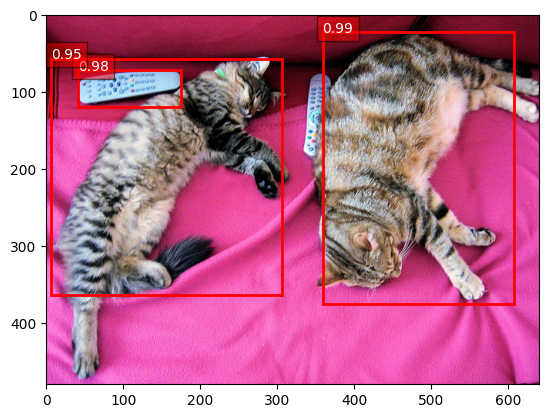

In [3]:
import matplotlib.patches as patches

def plot_detection(img, prediction, threshold=0.8):
    fig, ax = plt.subplots(1)
    ax.imshow(img)

    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    labels = prediction[0]['labels'].cpu().numpy()

    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            plt.text(box[0], box[1], f'{scores[i]:.2f}', color='white', bbox=dict(facecolor='red', alpha=0.5))

    plt.show()

plot_detection(image, prediction)

In [ ]:
import torch
import cv2
from PIL import Image
import numpy as np

# Load YOLOv5 model (will download automatically on first run)
print("Loading YOLOv5 model...")
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

# Configure to detect only people
model.classes = [0]  # Class 0 = person
model.conf = 0.25    # 25% confidence threshold

# Load your GIF
gif_path = "walk.gif"  # ← CHANGE THIS to your GIF path
gif = Image.open(gif_path)

# Extract frames
frames = []
try:
    while True:
        frames.append(np.array(gif.convert('RGB')))
        gif.seek(gif.tell() + 1)
except EOFError:
    pass

print(f"Processing {len(frames)} frames...")

# Process each frame
output_frames = []
for i, frame in enumerate(frames):
    # Detect people
    results = model(frame)
    
    # Draw detections on frame
    annotated = results.render()[0]  # returns BGR numpy array with boxes drawn
    
    # Convert back to RGB for PIL
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    # Add frame info
    num_people = len(results.pandas().xyxy[0])
    text = f"Frame {i+1}/{len(frames)} - People: {num_people}"
    cv2.putText(annotated_rgb, text, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    
    output_frames.append(Image.fromarray(annotated_rgb))
    print(f"Frame {i+1}: {num_people} people detected")

# Save output GIF
print("Saving output...")
output_frames[0].save(
    'output_detected.gif',
    save_all=True,
    append_images=output_frames[1:],
    duration=gif.info.get('duration', 100),
    loop=0
)

print("Done! Output saved to: output_detected.gif")